# Modele parametryczne – zbiór danych Heart Failure

Analiza czasu przeżycia (czas do zgonu) metodami parametrycznymi AFT (Accelerated Failure Time) dla pacjentów z niewydolnością serca.

- **Zmienna czasu**: `time` (dni od pierwszej wizyty)
- **Zdarzenie**: `DEATH_EVENT = 1` (zgon), `0` = cenzurowanie prawostronne
- **N = 299** obserwacji; 96 zgonów (32,1 %)

In [2]:
# Instalacja (odkomentuj jeśli potrzeba)
#!pip install lifelines pandas matplotlib numpy seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

print('Ksztalt danych:', df.shape)
print('Kolumny:', df.columns.tolist())
print()
print('Podstawowe statystyki:')
display(df.describe().round(2))
print()
print(f"Zdarzenia (zgony): {df['DEATH_EVENT'].sum()} "
      f"({df['DEATH_EVENT'].mean()*100:.1f}%)")
print(f"Cenzurowane:       {(df['DEATH_EVENT']==0).sum()} "
      f"({(df['DEATH_EVENT']==0).mean()*100:.1f}%)")


Ksztalt danych: (299, 13)
Kolumny: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Podstawowe statystyki:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00
mean,60.83,0.43,581.84,0.42,38.08,0.35,263358.03,1.39,136.63,0.65,0.32,130.26,0.32
std,11.89,0.50,970.29,0.49,11.83,0.48,97804.24,1.03,4.41,0.48,0.47,77.61,0.47
min,40.00,0.00,23.00,0.00,14.00,0.00,25100.00,0.50,113.00,0.00,0.00,4.00,0.00
25%,51.00,0.00,116.50,0.00,30.00,0.00,212500.00,0.90,134.00,0.00,0.00,73.00,0.00
50%,60.00,0.00,250.00,0.00,38.00,0.00,262000.00,1.10,137.00,1.00,0.00,115.00,0.00
75%,70.00,1.00,582.00,1.00,45.00,1.00,303500.00,1.40,140.00,1.00,1.00,203.00,1.00
max,95.00,1.00,7861.00,1.00,80.00,1.00,850000.00,9.40,148.00,1.00,1.00,285.00,1.00



Zdarzenia (zgony): 96 (32.1%)
Cenzurowane:       203 (67.9%)


## KOD 1 – Model Weibulla AFT

Model Weibulla AFT zakłada, że $\log(T) = \mu + \mathbf{x}^\top\boldsymbol{\beta} + \sigma\varepsilon$, gdzie $\varepsilon$ pochodzi z rozkładu Gumbela. Parametr $\rho$ (rho) opisuje kształt funkcji hazardu:
- $\rho < 1$ – hazard malejący
- $\rho = 1$ – hazard stały (rozkład wykładniczy)
- $\rho > 1$ – hazard rosnący

In [3]:
# Wszystkie zmienne objaśniające
variables = [
    'age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
    'ejection_fraction', 'high_blood_pressure', 'platelets',
    'serum_creatinine', 'serum_sodium', 'sex', 'smoking'
]

aft_weibull = WeibullAFTFitter()
aft_weibull.fit(
    df[variables + ['time', 'DEATH_EVENT']],
    duration_col='time', event_col='DEATH_EVENT'
)
aft_weibull.print_summary()


<lifelines.WeibullAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -628.12
         time fit was run = 2026-04-14 18:01:38 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                 
lambda_ age                      -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
        anaemia                  -0.50      0.61      0.22           -0.94           -0.06                0.39                0.94
        creatinine_phosphokinase -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        diabetes                 -0.15      0.86      0.23           -0.60            0.31                0.55                1.36
        ejection_fraction         0.05      1.05      0.01            0.03            0.08                1.03                1.08
        high_blood_pressure      -0.51      0.60      0.22           -0.95           -0.08                0.39                0.92
        platelets                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        serum_creatinine         -0.33      0.72      0.07           -0.48           -0.19                0.62                0.83
        serum_sodium              0.04      1.05      0.02           -0.00            0.09                1.00                1.10
        sex                       0.25      1.28      0.26           -0.27            0.76                0.76                2.14
        smoking                  -0.12      0.89      0.26           -0.63            0.39                0.53                1.48
        Intercept                 1.99      7.33      3.29           -4.46            8.44                0.01             4644.58
rho_    Intercept                -0.04      0.96      0.09           -0.21            0.14                0.81                1.15

                                  cmp to     z      p  -log2(p)
param   covariate                                              
lambda_ age                         0.00 -4.96 <0.005     20.41
        anaemia                     0.00 -2.24   0.03      5.30
        creatinine_phosphokinase    0.00 -2.34   0.02      5.70
        diabetes                    0.00 -0.63   0.53      0.92
        ejection_fraction           0.00  4.53 <0.005     17.38
        high_blood_pressure         0.00 -2.31   0.02      5.59
        platelets                   0.00  0.47   0.64      0.64
        serum_creatinine            0.00 -4.56 <0.005     17.57
        serum_sodium                0.00  1.87   0.06      4.01
        sex                         0.00  0.93   0.35      1.51
        smoking                     0.00 -0.45   0.65      0.62
        Intercept                   0.00  0.61   0.54      0.88
rho_    Intercept                   0.00 -0.43   0.67      0.58
---
Concordance = 0.74
AIC = 1282.24
log-likelihood ratio test = 84.64 on 11 df
-log2(p) of ll-ratio test = 42.29

## KOD 2 – Porównanie modeli AFT: Weibull vs Log-Normalny vs Log-Logistyczny

Porównujemy trzy rozkłady czasu przeżycia według:
- **AIC** (Akaike Information Criterion) – niższe = lepsze dopasowanie
- **C** (concordance index) – wyższe = lepsza dyskryminacja
- **Log-Likelihood** – miara dopasowania modelu

Porownanie modeli AFT (sortowane wg AIC):


,Model,AIC,Concordance,Log-Likelihood
0,Weibull AFT,1282.24,0.7406,-628.12
1,Log-Logistic AFT,1285.46,0.7399,-629.73
2,Log-Normal AFT,1287.37,0.7420,-630.69


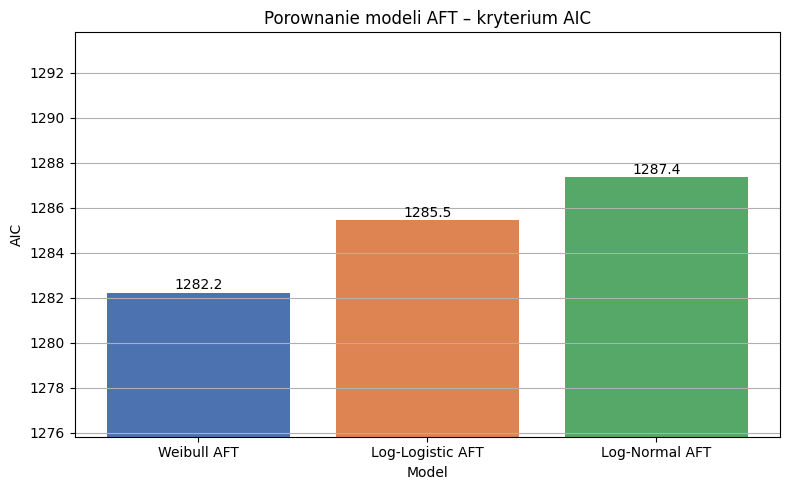

In [4]:
models = {
    'Weibull AFT':      WeibullAFTFitter(),
    'Log-Logistic AFT': LogLogisticAFTFitter(),
    'Log-Normal AFT':   LogNormalAFTFitter()
}

data = df[variables + ['time', 'DEATH_EVENT']]
results = []

for name, model in models.items():
    model.fit(data, duration_col='time', event_col='DEATH_EVENT')
    results.append({
        'Model': name,
        'AIC':           round(model.AIC_, 2),
        'Concordance':   round(model.concordance_index_, 4),
        'Log-Likelihood': round(model.log_likelihood_, 2)
    })

results_df = pd.DataFrame(results).sort_values('AIC')
print('Porownanie modeli AFT (sortowane wg AIC):')
display(results_df)

plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = plt.bar(results_df['Model'], results_df['AIC'], color=colors)
plt.title('Porownanie modeli AFT – kryterium AIC')
plt.ylabel('AIC')
plt.xlabel('Model')
y_min = min(results_df['AIC']) * 0.995
y_max = max(results_df['AIC']) * 1.005
plt.ylim(y_min, y_max)
for bar, val in zip(bars, results_df['AIC']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (y_max-y_min)*0.001,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('hf_aft_aic_comparison.png', dpi=150)
plt.show()


## KOD 3 – Szczegółowa analiza najlepszego modelu

Na podstawie AIC wybieramy model Log-Normalny AFT. Następnie:
1. Tworzymy zmienne dummy dla zmiennych binarnych
2. Eliminujemy nieistotne statystycznie predyktory (p > 0,05)
3. Prezentujemy funkcję przeżycia i hazardu dla różnych profili pacjentów

In [5]:
# Budowanie danych modelowych
cat_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
num_vars = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
            'platelets', 'serum_creatinine', 'serum_sodium']

dummies = pd.get_dummies(df[cat_vars], drop_first=True)
model_data = pd.concat([dummies, df[num_vars + ['time', 'DEATH_EVENT']]], axis=1)

# Model pełny
aft_lognorm = LogNormalAFTFitter()
aft_lognorm.fit(model_data, duration_col='time', event_col='DEATH_EVENT')
print('=== Model pelny – Log-Normalny AFT ===')
aft_lognorm.print_summary()


=== Model pelny – Log-Normalny AFT ===


<lifelines.LogNormalAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -630.69
         time fit was run = 2026-04-14 18:02:08 UTC

---
                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                 
mu_    age                      -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
       anaemia                  -0.52      0.59      0.25           -1.02           -0.03                0.36                0.97
       creatinine_phosphokinase -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
       diabetes                 -0.09      0.92      0.25           -0.59            0.41                0.56                1.51
       ejection_fraction         0.04      1.05      0.01            0.02            0.07                1.02                1.07
       high_blood_pressure      -0.50      0.60      0.26           -1.00           -0.00                0.37                1.00
       platelets                 0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       serum_creatinine         -0.36      0.70      0.10           -0.56           -0.15                0.57                0.86
       serum_sodium              0.06      1.06      0.03            0.01            0.11                1.01                1.12
       sex                       0.18      1.19      0.30           -0.40            0.76                0.67                2.13
       smoking                  -0.09      0.92      0.29           -0.66            0.49                0.52                1.62
       Intercept                -0.30      0.74      3.68           -7.51            6.92                0.00             1012.06
sigma_ Intercept                 0.49      1.63      0.08            0.33            0.65                1.40                1.91

                                 cmp to     z      p  -log2(p)
param  covariate                                              
mu_    age                         0.00 -4.51 <0.005     17.23
       anaemia                     0.00 -2.07   0.04      4.70
       creatinine_phosphokinase    0.00 -2.18   0.03      5.10
       diabetes                    0.00 -0.34   0.73      0.45
       ejection_fraction           0.00  3.84 <0.005     13.02
       high_blood_pressure         0.00 -1.97   0.05      4.35
       platelets                   0.00  0.54   0.59      0.77
       serum_creatinine            0.00 -3.44 <0.005     10.76
       serum_sodium                0.00  2.26   0.02      5.39
       sex                         0.00  0.59   0.55      0.86
       smoking                     0.00 -0.30   0.77      0.38
       Intercept                   0.00 -0.08   0.94      0.10
sigma_ Intercept                   0.00  6.12 <0.005     29.97
---
Concordance = 0.74
AIC = 1287.37
log-likelihood ratio test = 71.18 on 11 df
-log2(p) of ll-ratio test = 33.67

In [6]:
# Model zredukowany – tylko zmienne istotne statystycznie (p < 0.05)
# Na podstawie wynikow modelu pelnego
final_num = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium']
final_cat = ['anaemia', 'high_blood_pressure']

dummies_final = pd.get_dummies(df[final_cat], drop_first=True)
model_final = pd.concat(
    [dummies_final, df[final_num + ['time', 'DEATH_EVENT']]], axis=1
)

aft_final = LogNormalAFTFitter()
aft_final.fit(model_final, duration_col='time', event_col='DEATH_EVENT')
print('=== Model zredukowany – Log-Normalny AFT ===')
aft_final.print_summary()

aft_final.summary.to_excel('hf_aft_final_summary.xlsx')
print('Wyniki zapisane do hf_aft_final_summary.xlsx')


=== Model zredukowany – Log-Normalny AFT ===


<lifelines.LogNormalAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -633.28
         time fit was run = 2026-04-14 18:02:19 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                            
mu_    age                 -0.04      0.96      0.01           -0.07           -0.02                0.94                0.98
       anaemia             -0.42      0.66      0.25           -0.90            0.07                0.41                1.07
       ejection_fraction    0.04      1.04      0.01            0.02            0.07                1.02                1.07
       high_blood_pressure -0.48      0.62      0.25           -0.98            0.02                0.38                1.02
       serum_creatinine    -0.36      0.70      0.10           -0.57           -0.16                0.57                0.86
       serum_sodium         0.06      1.06      0.03            0.00            0.11                1.00                1.12
       Intercept            0.13      1.14      3.66           -7.04            7.31                0.00             1493.26
sigma_ Intercept            0.50      1.65      0.08            0.34            0.66                1.41                1.93

                            cmp to     z      p  -log2(p)
param  covariate                                         
mu_    age                    0.00 -4.31 <0.005     15.93
       anaemia                0.00 -1.69   0.09      3.44
       ejection_fraction      0.00  3.85 <0.005     13.02
       high_blood_pressure    0.00 -1.90   0.06      4.12
       serum_creatinine       0.00 -3.45 <0.005     10.82
       serum_sodium           0.00  2.11   0.03      4.85
       Intercept              0.00  0.04   0.97      0.04
sigma_ Intercept              0.00  6.25 <0.005     31.15
---
Concordance = 0.73
AIC = 1282.56
log-likelihood ratio test = 65.99 on 6 df
-log2(p) of ll-ratio test = 38.43

Wyniki zapisane do hf_aft_final_summary.xlsx


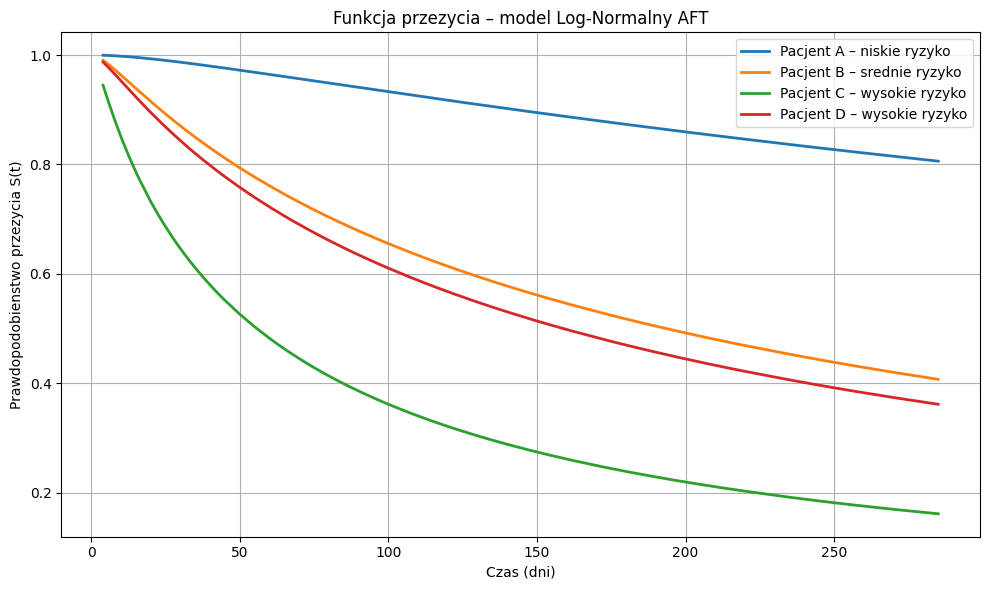

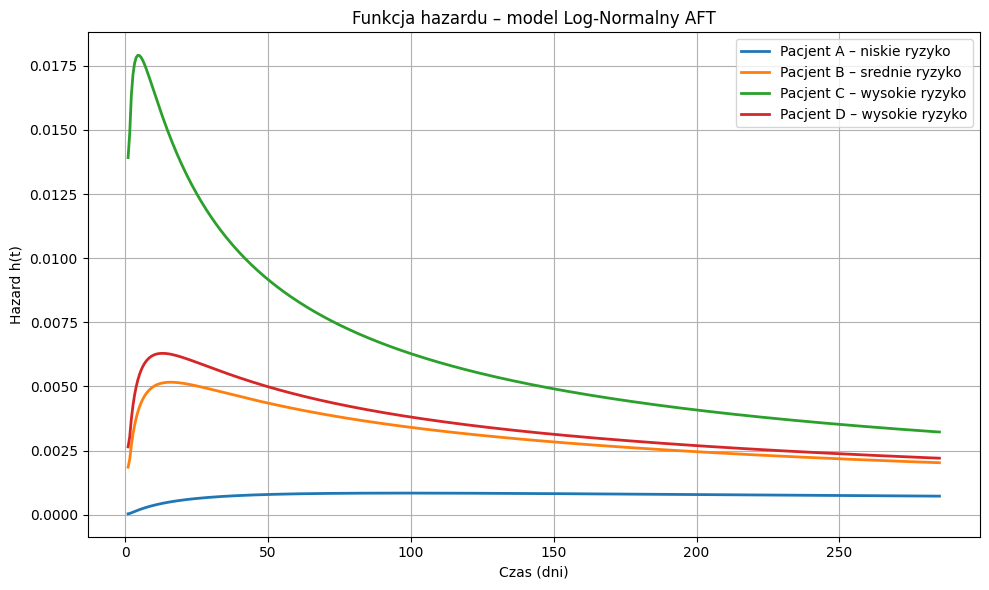

In [7]:
# Profile pacjentow do wizualizacji
profiles = pd.DataFrame({
    'anaemia':              [0,    1,    0,    1],
    'high_blood_pressure':  [0,    0,    1,    1],
    'age':                  [55,   65,   75,   55],
    'ejection_fraction':    [45,   30,   20,   25],
    'serum_creatinine':     [1.0,  1.5,  2.0,  1.2],
    'serum_sodium':         [138,  136,  134,  135]
})
labels = [
    'Pacjent A – niskie ryzyko',
    'Pacjent B – srednie ryzyko',
    'Pacjent C – wysokie ryzyko',
    'Pacjent D – wysokie ryzyko'
]

# Funkcja przezyycia
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, (_, row) in enumerate(profiles.iterrows()):
    sf = aft_final.predict_survival_function(row.to_frame().T)
    plt.plot(sf.index, sf.values.flatten(),
             label=labels[i], color=colors[i], linewidth=2)
plt.title('Funkcja przezycia – model Log-Normalny AFT')
plt.xlabel('Czas (dni)')
plt.ylabel('Prawdopodobienstwo przezycia S(t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hf_aft_survival_profiles.png', dpi=150)
plt.show()

# Funkcja hazardu
t_values = np.linspace(1, df['time'].max(), 500)

def compute_hazard(model, profile, t_vals):
    sf = model.predict_survival_function(profile, times=t_vals)
    S = np.clip(sf.values.flatten(), 1e-10, 1.0)
    return -np.gradient(np.log(S), t_vals)

plt.figure(figsize=(10, 6))
for i, (_, row) in enumerate(profiles.iterrows()):
    h = compute_hazard(aft_final, row.to_frame().T, t_values)
    plt.plot(t_values, h, label=labels[i], color=colors[i], linewidth=2)
plt.title('Funkcja hazardu – model Log-Normalny AFT')
plt.xlabel('Czas (dni)')
plt.ylabel('Hazard h(t)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hf_aft_hazard_profiles.png', dpi=150)
plt.show()


## KOD 4 – Cenzurowanie prawostronne

W zbiorze Heart Failure występuje **cenzurowanie prawostronne**: obserwacja kończy się, gdy pacjent przeżywa do końca okresu badania (lub wypada z badania) bez zarejestrowania zgonu. Wiemy jedynie, że przeżył *co najmniej* `time` dni.

**Cenzurowanie lewostronne** nie zachodzi – punkt startu obserwacji jest dokładnie znany dla każdego pacjenta. **Cenzurowanie interwałowe** również nie jest potrzebne – czas `time` jest wyrażony w dniach.

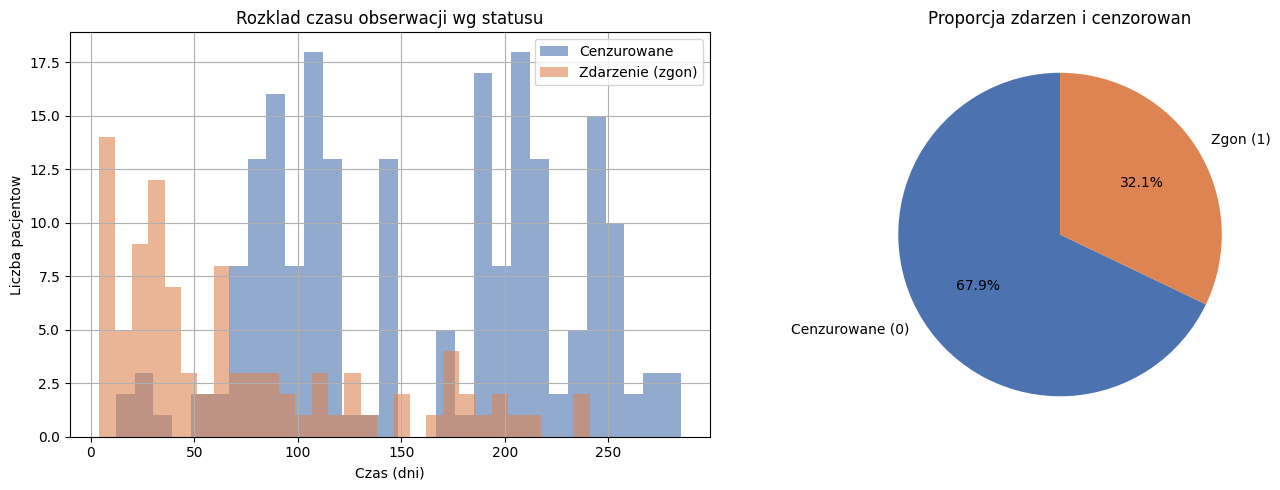

Laczna liczba obserwacji: 299
Cenzurowane (DEATH_EVENT=0): 203 (67.9%)
Zdarzenia (DEATH_EVENT=1):   96 (32.1%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, label, color in [(0, 'Cenzurowane', '#4C72B0'),
                              (1, 'Zdarzenie (zgon)', '#DD8452')]:
    mask = df['DEATH_EVENT'] == status
    axes[0].hist(df['time'][mask], bins=30, alpha=0.6,
                 label=label, color=color)
axes[0].set_title('Rozklad czasu obserwacji wg statusu')
axes[0].set_xlabel('Czas (dni)')
axes[0].set_ylabel('Liczba pacjentow')
axes[0].legend()
axes[0].grid(True)

counts = df['DEATH_EVENT'].value_counts()
axes[1].pie(counts, labels=['Cenzurowane (0)', 'Zgon (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90)
axes[1].set_title('Proporcja zdarzen i cenzorowan')

plt.tight_layout()
plt.savefig('hf_censoring.png', dpi=150)
plt.show()

print(f'Laczna liczba obserwacji: {len(df)}')
print(f"Cenzurowane (DEATH_EVENT=0): {(df['DEATH_EVENT']==0).sum()} "
      f"({(df['DEATH_EVENT']==0).mean()*100:.1f}%)")
print(f"Zdarzenia (DEATH_EVENT=1):   {df['DEATH_EVENT'].sum()} "
      f"({df['DEATH_EVENT'].mean()*100:.1f}%)")


## KOD 5 – Cenzurowanie interwałowe

W zbiorze Heart Failure **cenzurowanie interwałowe nie jest wymagane**. Czas do zgonu jest rejestrowany z dokładnością do jednego dnia, dlatego nie ma potrzeby modelowania przedziału, w którym zdarzenie mogło nastąpić. Zmienna `time` reprezentuje precyzyjny czas obserwacji.

## KOD 6 – Mediana przeżycia z bootstrapem

Estymujemy medianę czasu przeżycia każdego pacjenta wraz z odchyleniem standardowym przy użyciu metody bootstrap (100 iteracji).

In [9]:
n_iterations = 100
all_medians = []

np.random.seed(42)
for i in range(n_iterations):
    sample = model_final.sample(frac=1, replace=True).reset_index(drop=True)
    aft_bs = LogNormalAFTFitter()
    aft_bs.fit(sample, duration_col='time', event_col='DEATH_EVENT')
    all_medians.append(aft_bs.predict_median(model_final))

bootstrap_df = pd.concat(all_medians, axis=1)
mediany = aft_final.predict_median(model_final)
stds = bootstrap_df.std(axis=1)

wyniki = pd.DataFrame({
    'Mediana przezycia (dni)': mediany.round(1),
    'Odch. std. (bootstrap)':  stds.round(1)
})

print('Mediana przezycia z bootstrapem (pierwsze 20 pacjentow):')
display(wyniki.head(20))
print(f'Srednia mediana przezycia: {mediany.mean():.1f} dni')
print(f'Sred. odch. std. (bootstrap): {stds.mean():.1f} dni')

plt.figure(figsize=(10, 5))
plt.hist(mediany, bins=40, color='#4C72B0', edgecolor='white', alpha=0.8)
plt.axvline(mediany.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Srednia mediana = {mediany.mean():.0f} dni')
plt.title('Rozklad estymowanej mediany przezycia – model Log-Normalny AFT')
plt.xlabel('Mediana przezycia (dni)')
plt.ylabel('Liczba pacjentow')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hf_aft_median_distribution.png', dpi=150)
plt.show()


KeyboardInterrupt: 

In [ ]:
# Macierz kowariancji (COVB)
cov_df = pd.DataFrame(aft_final.variance_matrix_)
cov_df.to_excel('hf_aft_covariance_matrix.xlsx')
print('Macierz kowariancji (COVB):')
display(cov_df)
print('Macierz kowariancji zapisana do hf_aft_covariance_matrix.xlsx')
